# Comparação unificada das três metodologias de backlash

Este notebook constrói o mesmo multirrotor em três modalidades: `backlash.py`, `backlash_ross.py` e backlash nativo do ROSS. A análise verifica diretamente se a parcela linear `K_coupling * mesh.stiffness` foi somada à matriz global. Não há integração temporal: o foco é exclusivamente a montagem da matriz de rigidez.

## 1. Importações e carregamento das duas implementações externas

In [1]:
from copy import deepcopy
from importlib.util import module_from_spec, spec_from_file_location
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ross as rs

ROOT = Path(r'C:\Users\M\Desktop\doutorado\teste_backlash_ross')
BACKLASH_ORIGINAL_PATH = ROOT / 'mestrado' / 'backlash.py'
BACKLASH_K0_PATH = ROOT / 'teste_backlash_ross_K0' / 'backlash_ross.py'

def load_class(module_name, path):
    spec = spec_from_file_location(module_name, path)
    module = module_from_spec(spec)
    spec.loader.exec_module(module)
    return module.Backlash

BacklashOriginal = load_class('backlash_original_unificado', BACKLASH_ORIGINAL_PATH)
BacklashK0 = load_class('backlash_k0_unificado', BACKLASH_K0_PATH)
print('Original:', BACKLASH_ORIGINAL_PATH)
print('K0:', BACKLASH_K0_PATH)
print('ROSS:', Path(rs.__file__).resolve())

c:\Users\M\Documents\ROSS_DEV\venv\ross3\Lib\site-packages\ccp\__init__.py:135: UserWarning: c:\Users\M\Desktop\doutorado\teste_backlash_ross\comparacao_matrizes_backlash\REFPRP64.DLL.
REFPROP not configured. Automatically switching to EOS='HEOS' (CoolProp backend).
  _warnings.warn(
c:\Users\M\Documents\ROSS_DEV\venv\ross3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Original: C:\Users\M\Desktop\doutorado\teste_backlash_ross\mestrado\backlash.py
K0: C:\Users\M\Desktop\doutorado\teste_backlash_ross\teste_backlash_ross_K0\backlash_ross.py
ROSS: C:\Users\M\Documents\ROSS_DEV\ross\ross\__init__.py


## 2. Parâmetros comuns

As três metodologias usam a mesma geometria, mancais, massas, inércias, rotação, folga e erro de transmissão.

In [2]:
speed_rpm = 4500.0
omega = speed_rpm * np.pi / 30.0
z1 = z2 = 20
module = 0.01
width = 0.030
pressure_angle = np.radians(20.0)
gear_mass = 6.57
gear_inertia = 0.0365
bearing_stiffness = 1.0e8
bearing_damping = 512.64
backlash_value = 50e-6
error_amplitude = 20e-6
square_ratio = 0.275

LOCAL_LABELS = [
    'x_drive', 'y_drive', 'z_drive', 'rx_drive', 'ry_drive', 'theta_drive',
    'x_driven', 'y_driven', 'z_driven', 'rx_driven', 'ry_driven', 'theta_driven',
]

## 3. Função única de construção do multirrotor

O argumento `native_backlash=True` ativa o objeto de backlash diretamente no `MultiRotor` do ROSS. Nos outros dois casos, o `MultiRotor` convencional é entregue à classe externa correspondente.

In [3]:
def build_multirotor(native_backlash=False):
    steel = rs.Material(name='Steel', rho=7850, E=2e11, Poisson=0.3)
    stiff_steel = rs.Material(name='Steel_Stiff', rho=0.01, E=1e15, Poisson=0.3)
    shaft = [rs.ShaftElement(L=0.0001, idl=0.0, odl=0.0001, material=stiff_steel, n=0)]
    bearing = rs.BearingElement(
        n=0, kxx=bearing_stiffness, kyy=bearing_stiffness,
        cxx=bearing_damping, cyy=bearing_damping,
    )
    pitch_diameter = module * z1
    bore = np.sqrt(pitch_diameter**2 - 4*gear_mass/(np.pi*width*steel.rho))
    gear = rs.GearElementTVMS(
        n=0, material=steel, width=width, bore_diameter=bore, module=module,
        n_teeth=z1, pr_angle=pressure_angle, helix_angle=0.0,
        addendum_coeff=1.0, tip_clearance_coeff=0.25,
    )
    gear.m = gear_mass
    gear.Ip = gear_inertia
    gear.Id = 0.0001 * gear_inertia / 2.0
    rotor_drive = rs.Rotor(shaft_elements=shaft, disk_elements=[gear], bearing_elements=[bearing])
    rotor_driven = deepcopy(rotor_drive)

    kwargs = {}
    if native_backlash:
        kwargs['backlash'] = {
            'enable': True, 'initial_value': backlash_value,
            'error_amp': error_amplitude, 'smooth_operator': False, 'sigma': 1e5,
        }

    return rs.MultiRotor(
        driving_rotor=rotor_drive, driven_rotor=rotor_driven, coupled_nodes=(0, 0),
        update_mesh_stiffness=True,
        square_varying_stiffness={'enable': True, 'amplitude_ratio': square_ratio},
        orientation_angle=0.0, position='above', **kwargs,
    )

## 4. Ativação das três metodologias

In [4]:
base_original = build_multirotor(native_backlash=False)
obj_original = BacklashOriginal(
    base_original, omega, b0=backlash_value, error_amp=error_amplitude,
    gear_mesh_stiffness=None, num_points_cicle=10, n_cicles=1, cut_cicles=0,
    use_multirotor_coupling_stiffness=False,
)
model_original = obj_original.multirotor

base_k0 = build_multirotor(native_backlash=False)
obj_k0 = BacklashK0(
    base_k0, omega, b0=backlash_value, error_amp=error_amplitude,
    gear_mesh_stiffness=None, num_points_cicle=10, n_cicles=1, cut_cicles=0,
    use_multirotor_coupling_stiffness=False,
)
model_k0 = obj_k0.multirotor

model_native = build_multirotor(native_backlash=True)

print('Original: backlash externo criado =', obj_original is not None)
print('K0: backlash externo criado =', obj_k0 is not None)
print('ROSS nativo: mesh.backlash criado =', model_native.mesh.backlash is not None)

Original: backlash externo criado = True
K0: backlash externo criado = True
ROSS nativo: mesh.backlash criado = True


## 5. Extração consistente das matrizes

`K0` é montada exatamente como em `MultiRotor.K`, mas antes de chamar `add_coupling_stiffness`. `DeltaK = Kgear - K0gear` mostra o que foi acrescentado nos DOFs das engrenagens. `Kmesh_expected` é a contribuição local teórica `K_coupling * mesh.stiffness`.

In [5]:
def inspect_model(name, model):
    drive_dofs = list(model.mesh.driving_gear.dof_global_index.values())
    driven_dofs = list(model.mesh.driven_gear.dof_global_index.values())
    gear_dofs = drive_dofs + driven_dofs

    K_global = model.K(omega)
    K0_global = model._join_matrices(
        model.rotors['driving'].K(omega, omega),
        model.rotors['driven'].K(omega, omega * model.mesh.gear_ratio),
    )
    Kgear = K_global[np.ix_(gear_dofs, gear_dofs)]
    K0gear = K0_global[np.ix_(gear_dofs, gear_dofs)]
    delta = Kgear - K0gear
    expected = model.K_coupling * model.mesh.stiffness

    return {
        'name': name, 'model': model, 'gear_dofs': gear_dofs,
        'Kgear': Kgear, 'K0gear': K0gear, 'DeltaK': delta,
        'Kmesh_expected': expected,
        'mesh_stiffness': float(model.mesh.stiffness),
        'norm_delta': float(np.linalg.norm(delta)),
        'norm_expected': float(np.linalg.norm(expected)),
        'error_to_zero': float(np.linalg.norm(delta)),
        'error_to_expected': float(np.linalg.norm(delta - expected)),
    }

analyses = [
    inspect_model('backlash.py original', model_original),
    inspect_model('backlash_ross.py K0', model_k0),
    inspect_model('ROSS nativo', model_native),
]

## 6. Resumo numérico e classificação automática

In [6]:
rows = []
for item in analyses:
    scale = max(item['norm_expected'], 1.0)
    added = item['error_to_expected']/scale < 1e-10
    removed = item['error_to_zero']/scale < 1e-10
    rows.append({
        'metodologia': item['name'],
        'mesh.stiffness': item['mesh_stiffness'],
        '||DeltaK||': item['norm_delta'],
        '||Kmesh_expected||': item['norm_expected'],
        'erro para Kmesh': item['error_to_expected'],
        'coupling somado?': added,
        'coupling removido?': removed,
    })
summary = pd.DataFrame(rows).set_index('metodologia')
display(summary)

,mesh.stiffness,||DeltaK||,||Kmesh_expected||,erro para Kmesh,coupling somado?,coupling removido?
metodologia,,,,,,
backlash.py original,5.189461e+08,1.047057e+09,1.047057e+09,1.237469e-06,True,False
backlash_ross.py K0,5.189461e+08,0.000000e+00,1.047057e+09,1.047057e+09,False,True
ROSS nativo,5.189461e+08,0.000000e+00,1.047057e+09,1.047057e+09,False,True


## 7. Valores completos nos DOFs das engrenagens

Para cada metodologia são mostradas `Kgear`, `K0gear`, `DeltaK` e a contribuição teórica da malha. As linhas e colunas seguem a ordem local indicada em `LOCAL_LABELS`; os índices globais reais também são impressos.

In [7]:
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 240)
pd.set_option('display.float_format', lambda value: f'{value: .6e}')

for item in analyses:
    print('\n' + '='*90)
    print(item['name'])
    print('DOFs globais:', item['gear_dofs'])
    print('Kgear')
    display(pd.DataFrame(item['Kgear'], index=LOCAL_LABELS, columns=LOCAL_LABELS))
    print('K0gear')
    display(pd.DataFrame(item['K0gear'], index=LOCAL_LABELS, columns=LOCAL_LABELS))
    print('DeltaK = Kgear - K0gear')
    display(pd.DataFrame(item['DeltaK'], index=LOCAL_LABELS, columns=LOCAL_LABELS))
    print('Kmesh_expected = K_coupling * mesh.stiffness')
    display(pd.DataFrame(item['Kmesh_expected'], index=LOCAL_LABELS, columns=LOCAL_LABELS))


backlash.py original
DOFs globais: [0, 1, 2, 3, 4, 5, 12, 13, 14, 15, 16, 17]
Kgear


,x_drive,y_drive,z_drive,rx_drive,ry_drive,theta_drive,x_driven,y_driven,z_driven,rx_driven,ry_driven,theta_driven
x_drive,1.856847e+10,1.667861e+08,-7.434238e-09,0.000000e+00,9.203885e+05,1.667861e+07,-6.070516e+07,-1.667861e+08,7.434238e-09,0.000000e+00,-7.434238e-10,-1.667861e+07
y_drive,1.667861e+08,1.896601e+10,-2.042540e-08,-9.203885e+05,2.042540e-09,4.582409e+07,-1.667861e+08,-4.582409e+08,2.042540e-08,0.000000e+00,-2.042540e-09,-4.582409e+07
z_drive,-7.434238e-09,-2.042540e-08,7.853982e+10,0.000000e+00,-9.104316e-26,-2.042540e-09,7.434238e-09,2.042540e-08,-9.104316e-25,0.000000e+00,9.104316e-26,2.042540e-09
rx_drive,0.000000e+00,-9.203885e+05,0.000000e+00,9.510681e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
ry_drive,9.203885e+05,2.042540e-09,-9.104316e-26,0.000000e+00,9.510681e+01,2.042540e-10,-7.434238e-10,-2.042540e-09,9.104316e-26,0.000000e+00,-9.104316e-27,-2.042540e-10
theta_drive,1.667861e+07,4.582409e+07,-2.042540e-09,0.000000e+00,2.042540e-10,4.582447e+06,-1.667861e+07,-4.582409e+07,2.042540e-09,0.000000e+00,-2.042540e-10,-4.582409e+06
x_driven,-6.070516e+07,-1.667861e+08,7.434238e-09,0.000000e+00,-7.434238e-10,-1.667861e+07,1.856847e+10,1.667861e+08,-7.434238e-09,0.000000e+00,9.203885e+05,1.667861e+07
y_driven,-1.667861e+08,-4.582409e+08,2.042540e-08,0.000000e+00,-2.042540e-09,-4.582409e+07,1.667861e+08,1.896601e+10,-2.042540e-08,-9.203885e+05,2.042540e-09,4.582409e+07
z_driven,7.434238e-09,2.042540e-08,-9.104316e-25,0.000000e+00,9.104316e-26,2.042540e-09,-7.434238e-09,-2.042540e-08,7.853982e+10,0.000000e+00,-9.104316e-26,-2.042540e-09
rx_driven,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-9.203885e+05,0.000000e+00,9.510681e+01,0.000000e+00,0.000000e+00


K0gear


,x_drive,y_drive,z_drive,rx_drive,ry_drive,theta_drive,x_driven,y_driven,z_driven,rx_driven,ry_driven,theta_driven
x_drive,1.850777e+10,0.000000e+00,0.000000e+00,0.000000e+00,9.203885e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
y_drive,0.000000e+00,1.850777e+10,0.000000e+00,-9.203885e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
z_drive,0.000000e+00,0.000000e+00,7.853982e+10,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
rx_drive,0.000000e+00,-9.203885e+05,0.000000e+00,9.510681e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
ry_drive,9.203885e+05,0.000000e+00,0.000000e+00,0.000000e+00,9.510681e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
theta_drive,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.775953e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
x_driven,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.850777e+10,0.000000e+00,0.000000e+00,0.000000e+00,9.203885e+05,0.000000e+00
y_driven,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.850777e+10,0.000000e+00,-9.203885e+05,0.000000e+00,0.000000e+00
z_driven,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.853982e+10,0.000000e+00,0.000000e+00,0.000000e+00
rx_driven,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-9.203885e+05,0.000000e+00,9.510681e+01,0.000000e+00,0.000000e+00


DeltaK = Kgear - K0gear


...

,x_drive,y_drive,z_drive,rx_drive,ry_drive,theta_drive,x_driven,y_driven,z_driven,rx_driven,ry_driven,theta_driven
x_drive,1.850777e+10,0.000000e+00,0.000000e+00,0.000000e+00,9.203885e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
y_drive,0.000000e+00,1.850777e+10,0.000000e+00,-9.203885e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
z_drive,0.000000e+00,0.000000e+00,7.853982e+10,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
rx_drive,0.000000e+00,-9.203885e+05,0.000000e+00,9.510681e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
ry_drive,9.203885e+05,0.000000e+00,0.000000e+00,0.000000e+00,9.510681e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
theta_drive,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.775953e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
x_driven,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.850777e+10,0.000000e+00,0.000000e+00,0.000000e+00,9.203885e+05,0.000000e+00
y_driven,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.850777e+10,0.000000e+00,-9.203885e+05,0.000000e+00,0.000000e+00
z_driven,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.853982e+10,0.000000e+00,0.000000e+00,0.000000e+00
rx_driven,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-9.203885e+05,0.000000e+00,9.510681e+01,0.000000e+00,0.000000e+00


DeltaK = Kgear - K0gear


,x_drive,y_drive,z_drive,rx_drive,ry_drive,theta_drive,x_driven,y_driven,z_driven,rx_driven,ry_driven,theta_driven
x_drive,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
y_drive,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
z_drive,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
rx_drive,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
ry_drive,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
theta_drive,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
x_driven,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
y_driven,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
z_driven,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
rx_driven,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


Kmesh_expected = K_coupling * mesh.stiffness


,x_drive,y_drive,z_drive,rx_drive,ry_drive,theta_drive,x_driven,y_driven,z_driven,rx_driven,ry_driven,theta_driven
x_drive,6.070516e+07,1.667861e+08,-7.434238e-09,-0.000000e+00,7.434238e-10,1.667861e+07,-6.070516e+07,-1.667861e+08,7.434238e-09,0.000000e+00,-7.434238e-10,-1.667861e+07
y_drive,1.667861e+08,4.582409e+08,-2.042540e-08,-0.000000e+00,2.042540e-09,4.582409e+07,-1.667861e+08,-4.582409e+08,2.042540e-08,0.000000e+00,-2.042540e-09,-4.582409e+07
z_drive,-7.434238e-09,-2.042540e-08,9.104316e-25,0.000000e+00,-9.104316e-26,-2.042540e-09,7.434238e-09,2.042540e-08,-9.104316e-25,-0.000000e+00,9.104316e-26,2.042540e-09
rx_drive,-0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00
ry_drive,7.434238e-10,2.042540e-09,-9.104316e-26,-0.000000e+00,9.104316e-27,2.042540e-10,-7.434238e-10,-2.042540e-09,9.104316e-26,0.000000e+00,-9.104316e-27,-2.042540e-10
theta_drive,1.667861e+07,4.582409e+07,-2.042540e-09,-0.000000e+00,2.042540e-10,4.582409e+06,-1.667861e+07,-4.582409e+07,2.042540e-09,0.000000e+00,-2.042540e-10,-4.582409e+06
x_driven,-6.070516e+07,-1.667861e+08,7.434238e-09,0.000000e+00,-7.434238e-10,-1.667861e+07,6.070516e+07,1.667861e+08,-7.434238e-09,-0.000000e+00,7.434238e-10,1.667861e+07
y_driven,-1.667861e+08,-4.582409e+08,2.042540e-08,0.000000e+00,-2.042540e-09,-4.582409e+07,1.667861e+08,4.582409e+08,-2.042540e-08,-0.000000e+00,2.042540e-09,4.582409e+07
z_driven,7.434238e-09,2.042540e-08,-9.104316e-25,-0.000000e+00,9.104316e-26,2.042540e-09,-7.434238e-09,-2.042540e-08,9.104316e-25,0.000000e+00,-9.104316e-26,-2.042540e-09
rx_driven,0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00


## 8. Mapas de calor lado a lado

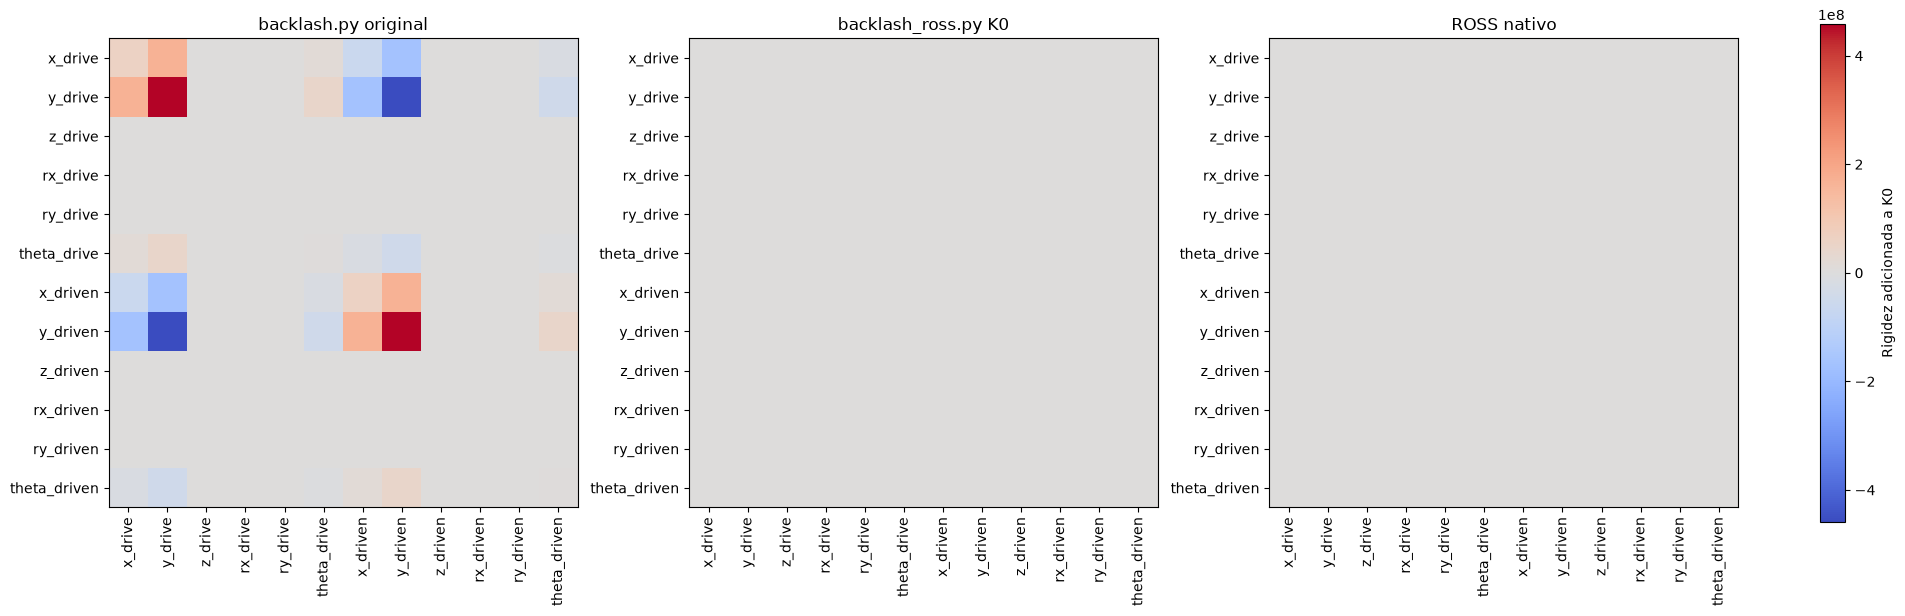

In [8]:
limit = max(np.max(np.abs(item['Kmesh_expected'])) for item in analyses)
fig, axes = plt.subplots(1, 3, figsize=(19, 6), constrained_layout=True)
for ax, item in zip(axes, analyses):
    image = ax.imshow(item['DeltaK'], cmap='coolwarm', vmin=-limit, vmax=limit)
    ax.set_title(item['name'])
    ax.set_xticks(range(12), LOCAL_LABELS, rotation=90)
    ax.set_yticks(range(12), LOCAL_LABELS)
fig.colorbar(image, ax=axes, label='Rigidez adicionada a K0')
plt.show()

## 9. Testes finais de consistência

In [9]:
original, k0_variant, native = analyses
np.testing.assert_allclose(original['DeltaK'], original['Kmesh_expected'], rtol=1e-12, atol=1e-6)
np.testing.assert_allclose(k0_variant['DeltaK'], 0.0, rtol=0.0, atol=0.0)
np.testing.assert_allclose(native['DeltaK'], 0.0, rtol=0.0, atol=0.0)
print('CONFIRMADO: backlash.py original soma K_coupling * mesh.stiffness.')
print('CONFIRMADO: backlash_ross.py retorna somente K0.')
print('CONFIRMADO: o backlash nativo do ROSS retorna somente K0.')

CONFIRMADO: backlash.py original soma K_coupling * mesh.stiffness.
CONFIRMADO: backlash_ross.py retorna somente K0.
CONFIRMADO: o backlash nativo do ROSS retorna somente K0.


## 10. Exportação opcional das matrizes para CSV

In [10]:
OUTPUT_DIR = ROOT / 'comparacao_matrizes_backlash' / 'resultados_csv'
OUTPUT_DIR.mkdir(exist_ok=True)
for item in analyses:
    slug = item['name'].lower().replace(' ', '_').replace('.', '')
    for matrix_name in ('Kgear', 'K0gear', 'DeltaK', 'Kmesh_expected'):
        pd.DataFrame(
            item[matrix_name], index=LOCAL_LABELS, columns=LOCAL_LABELS,
        ).to_csv(OUTPUT_DIR / f'{slug}_{matrix_name}.csv')
summary.to_csv(OUTPUT_DIR / 'resumo_comparacao.csv')
print('CSVs salvos em:', OUTPUT_DIR)

CSVs salvos em: C:\Users\M\Desktop\doutorado\teste_backlash_ross\comparacao_matrizes_backlash\resultados_csv
